In [1]:
import tensorflow as tf
import keras

In [76]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

val_size = 5000

x_valid = x_train[:val_size]
y_valid = y_train[:val_size]

x_train_new = x_train[val_size:]
y_train_new = y_train[val_size:]

# x_train = x_train.astype("float32") / 255.0
# x_valid = x_valid.astype("float32") / 255.0
# x_test  = x_test.astype("float32") / 255.0


print(x_train_new.shape, y_train_new.shape)  # (45000, 32, 32, 3), (45000, 1)
print(x_valid.shape, y_valid.shape)          # (5000, 32, 32, 3), (5000, 1)
print(x_test.shape, y_test.shape)            # (10000, 32, 32, 3), (10000, 1)


(45000, 32, 32, 3) (45000, 1)
(5000, 32, 32, 3) (5000, 1)
(10000, 32, 32, 3) (10000, 1)


In [77]:
model = keras.models.Sequential([
    keras.layers.Input(shape = (32,32,3)),
    keras.layers.Flatten()
])

hidden_layers = 20
n_neurons = 100

for _ in range(hidden_layers):
    model.add(keras.layers.Dense(n_neurons,activation=keras.activations.swish,kernel_initializer=keras.initializers.he_normal()))

model.add(keras.layers.Dense(10,activation='softmax'))
learning_rate = 1e-6
optimizer = keras.optimizers.Nadam(learning_rate)
early_stopping_cb = keras.callbacks.EarlyStopping(patience = 4)
model.compile(optimizer,loss = keras.losses.SparseCategoricalCrossentropy(),metrics= [keras.metrics.SparseCategoricalAccuracy()])


In [78]:
class LRfinder(keras.callbacks.Callback):
    def __init__(self,initial_lr = 1e-6,final_lr = 10,total_steps = 500):
        self.initial_lr = initial_lr
        self.final_lr = final_lr
        self.total_steps = total_steps
        self.lrs = []
        self.losses = []
        self.iteration = 0
    
    def on_batch_begin(self, batch, logs=None):
        lr = self.initial_lr * (self.final_lr / self.initial_lr) ** (self.iteration / self.total_steps)
        # tf.keras.backend.set_value(self.model.optimizer.learning_rate,lr) # Used to safely replace values
        self.model.optimizer.learning_rate.assign(lr) # Used to safely replace values above didnt work due to tensorflow issues , this is the safe way
        self.lrs.append(lr)
        self.iteration += 1
    
    def on_batch_end(self, batch, logs=None):
        self.losses.append(logs['loss']) # Contains logs such as loss , sparse_categorical_accuracy we defined abocve

In [79]:
lr_finder_instance = LRfinder(total_steps=200)
history = model.fit(x_train,y_train,epochs = 1,validation_data=(x_valid,y_valid),callbacks = [lr_finder_instance],batch_size=32,steps_per_epoch=lr_finder_instance.total_steps)

200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 30020329472.0000 - sparse_categorical_accuracy: 0.1145 - val_loss: 8.7292 - val_sparse_categorical_accuracy: 0.0972


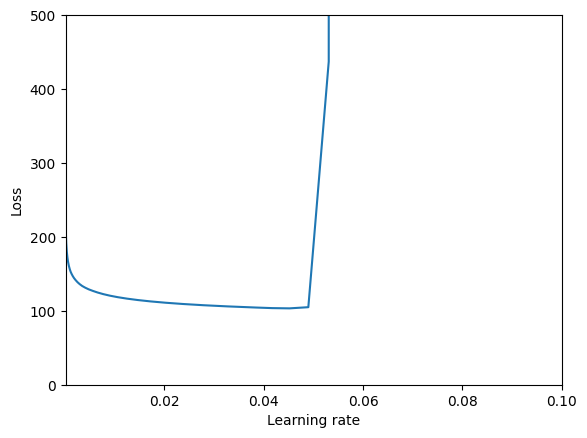

In [97]:
import matplotlib.pyplot as plt
plt.plot(lr_finder_instance.lrs, lr_finder_instance.losses)
# plt.xscale("log")
plt.xlabel("Learning rate")
plt.ylabel("Loss")
plt.xlim(1e-4, 1e-1)   # focus on 1e-6 to 1e-1
plt.ylim(0, 500)       # zoom in to loss between 0 and 500
plt.show()

'''
Found out LR where explosion happens is 0.05
Optimal LR = Exploding LR / 10 = 0.005 = 5e - 3
optimal LR = 5e - 3
'''

optimal_LR = 5e-3

In [98]:
from pathlib import Path
from time import strftime

def get_run_logdir(root_logdir="logs"):
    """
    Returns a unique log directory path for TensorBoard.
    Example: logs/run_2025_08_16-11_45_30
    """
    # timestamp for uniqueness
    run_id = strftime("run_%Y_%m_%d-%H_%M_%S")
    # construct full path
    logdir = Path(root_logdir) / run_id
    return str(logdir)


In [101]:
'''
Now using the optimal Learnign Rate to Run 20 epochs on the main data
'''

model = keras.models.Sequential([
    keras.layers.Input(shape = (32,32,3)),
    keras.layers.Flatten()
])

hidden_layers = 20
n_neurons = 100

for _ in range(hidden_layers):
    model.add(keras.layers.Dense(n_neurons,activation=keras.activations.swish,kernel_initializer=keras.initializers.he_normal()))

model.add(keras.layers.Dense(10,activation='softmax'))
learning_rate = 5e-3
optimizer = keras.optimizers.Nadam(learning_rate)
early_stopping_cb = keras.callbacks.EarlyStopping(patience = 4)
tensorboard_cb = keras.callbacks.TensorBoard(get_run_logdir())
model.compile(optimizer,loss = keras.losses.SparseCategoricalCrossentropy(),metrics= [keras.metrics.SparseCategoricalAccuracy()])
history = model.fit(x_train,y_train,epochs = 200,validation_data=(x_valid,y_valid),callbacks = [early_stopping_cb,tensorboard_cb],batch_size=32)

Epoch 1/200
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - loss: 37.3045 - sparse_categorical_accuracy: 0.1613 - val_loss: 2.0985 - val_sparse_categorical_accuracy: 0.2076
Epoch 2/200
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 1.9890 - sparse_categorical_accuracy: 0.2474 - val_loss: 1.9503 - val_sparse_categorical_accuracy: 0.2558
Epoch 3/200
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 33.4577 - sparse_categorical_accuracy: 0.2564 - val_loss: 2.3145 - val_sparse_categorical_accuracy: 0.0920
Epoch 4/200
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 2.3051 - sparse_categorical_accuracy: 0.0976 - val_loss: 2.3026 - val_sparse_categorical_accuracy: 0.0976
Epoch 5/200
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 2.3033 - sparse_categorical_accuracy: 0.1010 - val_loss: 2.3028 - val_sparse_categorical_accuracy: 0.1038
Epoch 6/200
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 2.3030 - sparse_categorical_accuracy: 0.1041 - val_loss: 2.3034 - val_sparse_categorical_

In [103]:
%load_ext tensorboard
%tensorboard --logdir=./logs/

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6006 (pid 14340), started 0:00:04 ago. (Use '!kill 14340' to kill it.)

In [ ]:
'''
Trying to add Batch Normalization and compare results
'''

'''
Finding right Learning rate for batch Normalization
'''

model = keras.models.Sequential([
    keras.layers.Input(shape = (32,32,3)),
    keras.layers.Flatten(),
    keras.layers.BatchNormalization()
])

hidden_layers = 20
n_neurons = 100

for _ in range(hidden_layers):
    model.add(keras.layers.Dense(n_neurons,activation=keras.activations.swish,kernel_initializer=keras.initializers.he_normal()))
    model.add(keras.layers.BatchNormalization())


model.add(keras.layers.Dense(10,activation='softmax'))
early_stopping_cb = keras.callbacks.EarlyStopping(patience = 4)
tensorboard_cb = keras.callbacks.TensorBoard(get_run_logdir())
lr_finder_instance = LRfinder(total_steps=500)
learning_rate = lr_finder_instance.initial_lr
optimizer = keras.optimizers.Nadam(learning_rate)

model.compile(optimizer,loss = keras.losses.SparseCategoricalCrossentropy(),metrics= [keras.metrics.SparseCategoricalAccuracy()])
history = model.fit(x_train,y_train,epochs = 1,validation_data=(x_valid,y_valid),callbacks = [lr_finder_instance],batch_size=32,steps_per_epoch=lr_finder_instance.total_steps)

500/500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 37.4616 - sparse_categorical_accuracy: 0.1049 - val_loss: 2496549234424439316626846777344.0000 - val_sparse_categorical_accuracy: 0.1040


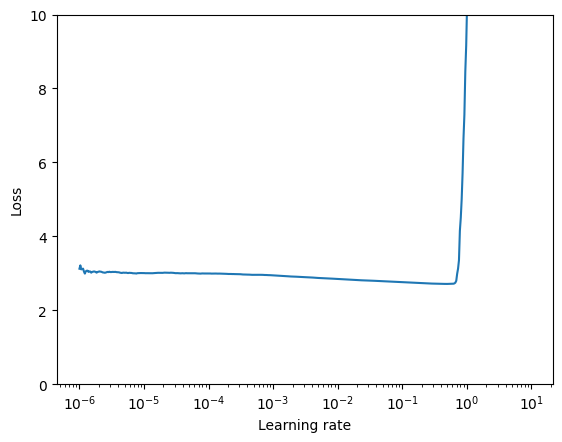

In [130]:
import matplotlib.pyplot as plt
plt.plot(lr_finder_instance.lrs, lr_finder_instance.losses)
plt.xscale("log")
plt.xlabel("Learning rate")
plt.ylabel("Loss")
# plt.xlim(1e-4, 1) 
plt.ylim(0, 10)       
'''
Found out LR where explosion happens is 0.05
Optimal LR = Exploding LR / 10 = 0.005 = 5e - 3
optimal LR = 5e - 3 Again
'''
plt.show()

In [131]:
'''
Trying to add Batch Normalization and compare results
'''

'''
Found optimal LR as 5e - 3 , Trying Batch Normalization for whole train set now
'''

model = keras.models.Sequential([
    keras.layers.Input(shape = (32,32,3)),
    keras.layers.Flatten(),
    keras.layers.BatchNormalization()
])

hidden_layers = 20
n_neurons = 100

for _ in range(hidden_layers):
    model.add(keras.layers.Dense(n_neurons,activation=keras.activations.swish,kernel_initializer=keras.initializers.he_normal()))
    model.add(keras.layers.BatchNormalization())

model.add(keras.layers.Dense(10,activation='softmax'))

early_stopping_cb = keras.callbacks.EarlyStopping(patience = 4)
tensorboard_cb = keras.callbacks.TensorBoard(get_run_logdir())
lr_finder_instance = LRfinder(total_steps=500)
learning_rate = 5e-3
optimizer = keras.optimizers.Nadam(learning_rate)

model.compile(optimizer,loss = keras.losses.SparseCategoricalCrossentropy(),metrics= [keras.metrics.SparseCategoricalAccuracy()])
history = model.fit(x_train,y_train,epochs = 200,validation_data=(x_valid,y_valid),callbacks = [early_stopping_cb,tensorboard_cb],batch_size=32)

Epoch 1/200
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 2.1848 - sparse_categorical_accuracy: 0.2098 - val_loss: 1.8650 - val_sparse_categorical_accuracy: 0.3168
Epoch 2/200
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 1.8692 - sparse_categorical_accuracy: 0.3211 - val_loss: 1.7890 - val_sparse_categorical_accuracy: 0.3788
Epoch 3/200
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 1.7942 - sparse_categorical_accuracy: 0.3572 - val_loss: 1.7225 - val_sparse_categorical_accuracy: 0.3642
Epoch 4/200
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 1.7481 - sparse_categorical_accuracy: 0.3761 - val_loss: 1.8945 - val_sparse_categorical_accuracy: 0.3916
Epoch 5/200
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 1.7047 - sparse_categorical_accuracy: 0.3879 - val_loss: 1.7620 - val_sparse_categorical_accuracy: 0.4162
Epoch 6/200
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 1.6683 - sparse_categorical_accuracy: 0.4093 - val_loss: 1.6249 - val_sparse_categoric

In [165]:
'''
Now we will try SELU activation function and make the network configuration such that it self-normalizes instead of Batch Normalization and find optimal LR
'''
model = keras.models.Sequential([
    keras.layers.Input(shape = (32,32,3)),
    keras.layers.Flatten()
])

hidden_layers = 20
n_neurons = 100

for _ in range(hidden_layers):
    model.add(keras.layers.Dense(n_neurons,activation=keras.activations.selu,kernel_initializer=keras.initializers.lecun_normal())) # Le-cun initialization and selu activation function

model.add(keras.layers.Dense(10,activation='softmax'))

early_stopping_cb = keras.callbacks.EarlyStopping(patience = 4)
tensorboard_cb = keras.callbacks.TensorBoard(get_run_logdir())
lr_finder_instance = LRfinder(final_lr=20,total_steps=500)
learning_rate = lr_finder_instance.initial_lr
optimizer = keras.optimizers.Nadam(learning_rate)

X_means = x_train.mean(axis=0)
X_stds = x_train.std(axis=0)
X_train_scaled = (x_train - X_means) / X_stds
X_valid_scaled = (x_valid - X_means) / X_stds
X_test_scaled = (x_test - X_means) / X_stds

model.compile(optimizer,loss = keras.losses.SparseCategoricalCrossentropy(),metrics= [keras.metrics.SparseCategoricalAccuracy()])
history = model.fit(X_train_scaled,y_train,epochs = 1,validation_data=(X_valid_scaled,y_valid),callbacks = [lr_finder_instance],batch_size=32,steps_per_epoch=lr_finder_instance.total_steps)

500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 20637780.0000 - sparse_categorical_accuracy: 0.1554 - val_loss: 790.9196 - val_sparse_categorical_accuracy: 0.1038


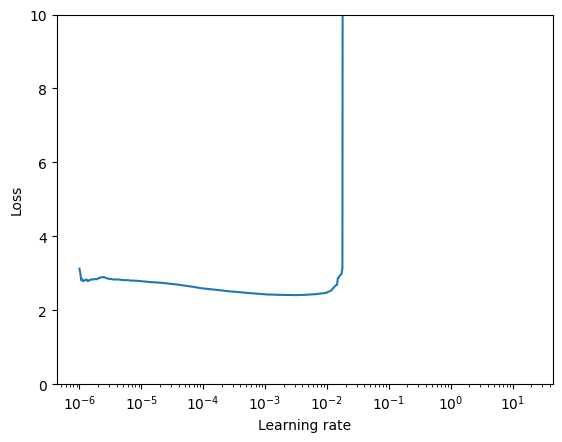

In [ ]:
import matplotlib.pyplot as plt
plt.plot(lr_finder_instance.lrs, lr_finder_instance.losses)
plt.xscale("log")
plt.xlabel("Learning rate")
plt.ylabel("Loss")
# plt.xlim(1e-4, 1) 
plt.ylim(0, 10)  
'''
Found out LR where explosion happens is 0.02
Optimal LR = Exploding LR / 10 = 0.005 = 1e - 3
optimal LR = 1e - 3 Again
'''
 
plt.show() 

In [169]:
'''
Found Optimal LR = 1e - 3 again
'''
'''
Now we will try SELU activation function and make the network configuration such that it self-normalizes
'''
model = keras.models.Sequential([
    keras.layers.Input(shape = (32,32,3)),
    keras.layers.Flatten()
])


hidden_layers = 20
n_neurons = 100

for _ in range(hidden_layers):
    model.add(keras.layers.Dense(n_neurons,activation=keras.activations.selu,kernel_initializer=keras.initializers.lecun_normal())) # Le-cun initialization and selu activation function

model.add(keras.layers.Dense(10,activation='softmax'))

early_stopping_cb = keras.callbacks.EarlyStopping(patience = 3)
tensorboard_cb = keras.callbacks.TensorBoard(get_run_logdir())
lr_finder_instance = LRfinder(final_lr=20,total_steps=500)
learning_rate = 1e-3
optimizer = keras.optimizers.Nadam(learning_rate)

X_means = x_train.mean(axis=0)
X_stds = x_train.std(axis=0)
X_train_scaled = (x_train - X_means) / X_stds
X_valid_scaled = (x_valid - X_means) / X_stds
X_test_scaled = (x_test - X_means) / X_stds

model.compile(optimizer,loss = keras.losses.SparseCategoricalCrossentropy(),metrics= [keras.metrics.SparseCategoricalAccuracy()])
history = model.fit(X_train_scaled,y_train,epochs = 200,validation_data=(X_valid_scaled,y_valid),callbacks = [early_stopping_cb,tensorboard_cb],batch_size=32)


Epoch 1/200
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - loss: 2.0837 - sparse_categorical_accuracy: 0.2524 - val_loss: 1.7861 - val_sparse_categorical_accuracy: 0.3556
Epoch 2/200
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 1.7709 - sparse_categorical_accuracy: 0.3659 - val_loss: 1.7584 - val_sparse_categorical_accuracy: 0.3694
Epoch 3/200
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 1.6694 - sparse_categorical_accuracy: 0.4037 - val_loss: 1.5607 - val_sparse_categorical_accuracy: 0.4470
Epoch 4/200
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - loss: 1.6178 - sparse_categorical_accuracy: 0.4283 - val_loss: 1.5266 - val_sparse_categorical_accuracy: 0.4616
Epoch 5/200
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - loss: 1.5493 - sparse_categorical_accuracy: 0.4532 - val_loss: 1.4500 - val_sparse_categorical_accuracy: 0.4818
Epoch 6/200
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - loss: 1.5191 - sparse_categorical_accuracy: 0.4582 - val_loss: 1.4700 - val_sparse_categori

In [170]:
%load_ext tensorboard
%tensorboard --logdir=./logs/

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6006 (pid 14340), started 0:52:41 ago. (Use '!kill 14340' to kill it.)

In [ ]:
'''
Now we will try alpha-dropout on the self-regularizing net
'''

model = keras.models.Sequential([
    keras.layers.Input(shape = (32,32,3)),
    keras.layers.Flatten(),
    # keras.layers.AlphaDropout(rate = 0.2) # Alpha-DRopout for self-regularizing nets Poor accuracy reached so dropping it
])


hidden_layers = 20
n_neurons = 100

for _ in range(hidden_layers):
    model.add(keras.layers.Dense(n_neurons,activation=keras.activations.selu,kernel_initializer=keras.initializers.lecun_normal())) # Le-cun initialization and selu activation function
    # model.add(keras.layers.AlphaDropout(rate = 0.2)) # Tries adding this poor accuracy

keras.layers.AlphaDropout(rate = 0.2) # Many SOTA models do like this adding dropout after the last dense layer
model.add(keras.layers.Dense(10,activation='softmax'))

early_stopping_cb = keras.callbacks.EarlyStopping(patience = 3)
tensorboard_cb = keras.callbacks.TensorBoard(get_run_logdir())
model_checkpoint_cb = keras.callbacks.ModelCheckpoint(
    "my_cifar10_alpha_dropout_model.keras", save_best_only=True)
lr_finder_instance = LRfinder(final_lr=20,total_steps=500)
learning_rate = 1e-3
optimizer = keras.optimizers.Nadam(learning_rate)

X_means = x_train.mean(axis=0)
X_stds = x_train.std(axis=0)
X_train_scaled = (x_train - X_means) / X_stds
X_valid_scaled = (x_valid - X_means) / X_stds
X_test_scaled = (x_test - X_means) / X_stds

model.compile(optimizer,loss = keras.losses.SparseCategoricalCrossentropy(),metrics= [keras.metrics.SparseCategoricalAccuracy()])
history = model.fit(X_train_scaled,y_train,epochs = 200,validation_data=(X_valid_scaled,y_valid),callbacks = [early_stopping_cb,tensorboard_cb,model_checkpoint_cb],batch_size=32)


Epoch 1/200
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 2.0401 - sparse_categorical_accuracy: 0.2671 - val_loss: 1.7564 - val_sparse_categorical_accuracy: 0.3688
Epoch 2/200
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 1.7314 - sparse_categorical_accuracy: 0.3840 - val_loss: 1.5990 - val_sparse_categorical_accuracy: 0.4268
Epoch 3/200
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 1.6474 - sparse_categorical_accuracy: 0.4160 - val_loss: 1.5347 - val_sparse_categorical_accuracy: 0.4464
Epoch 4/200
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 1.5792 - sparse_categorical_accuracy: 0.4443 - val_loss: 1.5917 - val_sparse_categorical_accuracy: 0.4400
Epoch 5/200
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 1.5377 - sparse_categorical_accuracy: 0.4587 - val_loss: 1.4813 - val_sparse_categorical_accuracy: 0.4712
Epoch 6/200
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 1.4958 - sparse_categorical_accuracy: 0.4766 - val_loss: 1.4916 - val_sparse_categorical_ac

[<Flatten name=flatten_31, built=True>,
 <Dense name=dense_672, built=True>,
 <Dense name=dense_673, built=True>,
 <Dense name=dense_674, built=True>,
 <Dense name=dense_675, built=True>,
 <Dense name=dense_676, built=True>,
 <Dense name=dense_677, built=True>,
 <Dense name=dense_678, built=True>,
 <Dense name=dense_679, built=True>,
 <Dense name=dense_680, built=True>,
 <Dense name=dense_681, built=True>,
 <Dense name=dense_682, built=True>,
 <Dense name=dense_683, built=True>,
 <Dense name=dense_684, built=True>,
 <Dense name=dense_685, built=True>,
 <Dense name=dense_686, built=True>,
 <Dense name=dense_687, built=True>,
 <Dense name=dense_688, built=True>,
 <Dense name=dense_689, built=True>,
 <Dense name=dense_690, built=True>,
 <Dense name=dense_691, built=True>,
 <Dense name=dense_692, built=True>]

In [175]:
#Using Monte-Carlo Alpha Dropout instead of alpha Dropout
import numpy as np

class MCAlphaDropout(keras.layers.AlphaDropout):
    def call(self, inputs):
        return super().call(inputs, training=True)

mc_model = keras.Sequential([
    (
        MCAlphaDropout(layer.rate)
        if isinstance(layer, keras.layers.AlphaDropout)
        else layer
    )
    for layer in model.layers
])

In [176]:
def mc_dropout_predict_probas(mc_model, X, n_samples=10):
    Y_probas = [mc_model.predict(X) for sample in range(n_samples)]
    return np.mean(Y_probas, axis=0)

def mc_dropout_predict_classes(mc_model, X, n_samples=10):
    Y_probas = mc_dropout_predict_probas(mc_model, X, n_samples)
    return Y_probas.argmax(axis=1)

In [203]:
tf.random.set_seed(42)

y_pred = mc_dropout_predict_classes(mc_model, X_valid_scaled)
accuracy = (y_pred == y_valid[:, 0]).mean()
accuracy

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


0.6092

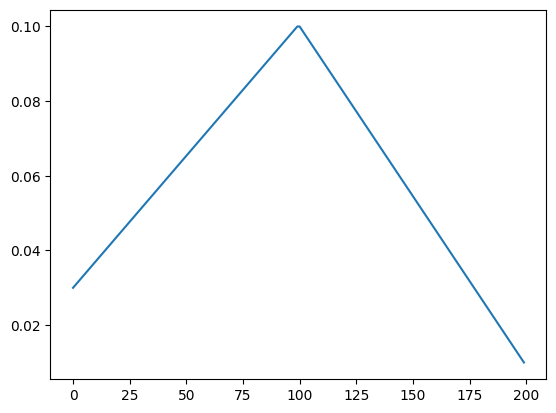

In [202]:
initial_value = 0.03
peak_value = 0.1
final_value = 0.01
n_steps = 200
peak_steps = int(n_steps / 2)  # 100

# Linear increase: step 0 to 99 (peak_steps)
values_till_first_peak = [
    initial_value + (peak_value - initial_value) * (i / (peak_steps - 1))
    for i in range(peak_steps)
]

# Linear decrease: step 100 to 199 (n_steps - peak_steps)
values_in_decline = [
    peak_value + (final_value - peak_value) * ((i - peak_steps) / (n_steps - peak_steps - 1))
    for i in range(peak_steps, n_steps)
]

# Full schedule
lr_values = values_till_first_peak + values_in_decline



plt.plot(np.arange(200),lr_values)
plt.show()

In [ ]:
def interpolate(start, end, current_step, total_steps):
    """
    Linearly interpolates between start and end value.
    """
    return start + (end - start) * (current_step / (total_steps - 1))


# Alterantively we can also use numpy functions


In [199]:
# Interpolate one value at index step
step = 20
x = [0, 99]
y = [0.03, 0.1]
value = np.interp(step, x, y)
value

0.04414141414141414

In [ ]:
np.linspace(0.03, 0.1, num=100)

1

In [213]:
import numpy as np
import math

class OneCycleScheduler(keras.callbacks.Callback):
    def __init__(self, start_lr, peak_lr, end_lr, n_epochs, n_samples, batch_size):
        self.start_lr = start_lr
        self.peak_lr = peak_lr
        self.end_lr = end_lr
        self.n_epochs = n_epochs
        self.batch_number = 0
        self.total_steps = math.ceil(n_samples / batch_size) * n_epochs
        self.half_steps = self.total_steps // 2

    def on_train_batch_begin(self, batch, logs=None):
        if self.batch_number <= self.half_steps:
            # Warmup
            new_lr = np.interp(self.batch_number,[0, self.half_steps],[self.start_lr, self.peak_lr])
        else:
            # Cooldown
            new_lr = np.interp(self.batch_number,[self.half_steps, self.total_steps],[self.peak_lr, self.end_lr])

        self.model.optimizer.learning_rate.assign(new_lr)
        self.batch_number += 1


In [215]:
'''
Using One cycle scheduler with self-normalizing Nets
'''

model = keras.models.Sequential([
    keras.layers.Input(shape = (32,32,3)),
    keras.layers.Flatten(),
    # keras.layers.AlphaDropout(rate = 0.2) # Alpha-DRopout for self-regularizing nets Poor accuracy reached so dropping it
])


hidden_layers = 20
n_neurons = 100

for _ in range(hidden_layers):
    model.add(keras.layers.Dense(n_neurons,activation=keras.activations.selu,kernel_initializer=keras.initializers.lecun_normal())) # Le-cun initialization and selu activation function
    # model.add(keras.layers.AlphaDropout(rate = 0.2)) # Tries adding this poor accuracy

keras.layers.AlphaDropout(rate = 0.2) # Many SOTA models do like this adding dropout after the last dense layer
model.add(keras.layers.Dense(10,activation='softmax'))

early_stopping_cb = keras.callbacks.EarlyStopping(patience = 3)
tensorboard_cb = keras.callbacks.TensorBoard(get_run_logdir())
model_checkpoint_cb = keras.callbacks.ModelCheckpoint(
    "cifar10_final_model.keras", save_best_only=True)
lr_finder_instance_cb = LRfinder(final_lr=20,total_steps=500)

n_epochs = 50
one_cycle_cb = OneCycleScheduler(5e-4,5e-3,1e-4,n_epochs,len(x_train),128)

learning_rate = 1e-3
optimizer = keras.optimizers.Nadam(learning_rate)

X_means = x_train.mean(axis=0)
X_stds = x_train.std(axis=0)
X_train_scaled = (x_train - X_means) / X_stds
X_valid_scaled = (x_valid - X_means) / X_stds
X_test_scaled = (x_test - X_means) / X_stds

model.compile(optimizer,loss = keras.losses.SparseCategoricalCrossentropy(),metrics= [keras.metrics.SparseCategoricalAccuracy()])
history = model.fit(X_train_scaled,y_train,epochs = n_epochs,validation_data=(X_valid_scaled,y_valid),callbacks = [one_cycle_cb,tensorboard_cb,model_checkpoint_cb],batch_size=128)


Epoch 1/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - loss: 1.9762 - sparse_categorical_accuracy: 0.3001 - val_loss: 1.6485 - val_sparse_categorical_accuracy: 0.4070
Epoch 2/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 1.6688 - sparse_categorical_accuracy: 0.4027 - val_loss: 1.5330 - val_sparse_categorical_accuracy: 0.4504
Epoch 3/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 1.5745 - sparse_categorical_accuracy: 0.4409 - val_loss: 1.4628 - val_sparse_categorical_accuracy: 0.4780
Epoch 4/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 1.5217 - sparse_categorical_accuracy: 0.4637 - val_loss: 1.4770 - val_sparse_categorical_accuracy: 0.4746
Epoch 5/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 1.4867 - sparse_categorical_accuracy: 0.4782 - val_loss: 1.4101 - val_sparse_categorical_accuracy: 0.4994
Epoch 6/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 1.4453 - sparse_categorical_accuracy: 0.4934 - val_loss: 1.3952 - val_sparse_categorical_accuracy: 0.5130
Epo

In [219]:
%load_ext tensorboard
%tensorboard --logdir=./logs/

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6006 (pid 14340), started 6:14:26 ago. (Use '!kill 14340' to kill it.)

In [220]:
max(history.history['val_sparse_categorical_accuracy'])

0.5547999739646912

In [221]:
'''
Final Accuracy 55 %
'''

'\nFinal Accuracy 55 %\n'